In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
from scipy import sparse
from sklearn.decomposition import TruncatedSVD, PCA

In [2]:
from sklearn.preprocessing import normalize
import warnings
warnings.filterwarnings('ignore',category=UserWarning)

In [ ]:
#pip install umap-learn

In [20]:
# Attempt UMAP import
try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False
    print("umap-learn not installed. UMAP comparison will be skipped.")
    print("Install with: pip install umap-learn")

In [3]:
# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [4]:
# Paths
OUTPUTS_DIR = "outputs/"
FIGURES_DIR = "figures/"

import os
os.makedirs(FIGURES_DIR,exist_ok=True)

## 1 - Load Upstream Data

In [5]:
def load_pkl(filename):
    """Load a pkl file from outputs/. Returns the raw object. """
    path=os.path.join(OUTPUTS_DIR,filename)
    with open(path,"rb")as f:
        obj=pickle.load(f)
    return obj

#---TF-IDF---
tfidf_uni_data=load_pkl("tfidf_unigram_matrix.pkl")
tfidf_bi_data=load_pkl("tfidf_bigram_matrix.pkl")

#Extract components from dict structure
#tfidf_.pkl format: {"matrix":csr_matrix, 'vectorizer':...,"index":...,"period":...,"era":...}
tfidf_uni_matrix=tfidf_uni_data["matrix"]
tfidf_bi_matrix=tfidf_bi_data["matrix"]
period_labels=tfidf_uni_data['period']
era_labels=tfidf_uni_data['era']

print(f"TF-IDF Unigram:{tfidf_uni_matrix.shape}(sparse,nnz={tfidf_uni_matrix.nnz})")
print(f"TF-IDF Bigram:{tfidf_bi_matrix.shape}(sparse,nnz={tfidf_bi_matrix.nnz})")
print(f"Petiod labels:{np.unique(period_labels)}")
print(f"Era labels:{np.unique(era_labels)}")
print(f"Samples per period:{ {p:(period_labels==p).sum() for p in sorted(np.unique(period_labels))} }")

TF-IDF Unigram:(32221, 13149)(sparse,nnz=2135015)
TF-IDF Bigram:(32221, 20000)(sparse,nnz=827982)
Petiod labels:['1991-1995' '1996-2000' '2001-2005' '2006-2010' '2011-2015' '2016-2021']
Era labels:['Deep Learning' 'Machine Learning' 'Statistical Methods'
 'Transformer & Pre-training']
Samples per period:{'1991-1995': 448, '1996-2000': 659, '2001-2005': 279, '2006-2010': 364, '2011-2015': 2066, '2016-2021': 28405}


In [ ]:
#---SBERT & LDA---
"""
sbert_data=load_pkl("sbert_matrix.pkl")
lda_data=load_pkl("lda_matrix.pkl")

"""

## 2 - Explained Variance Elbow Plot

## Before choosing how many SVD components to keep in stage 1, examine how explained variance accumulates. 

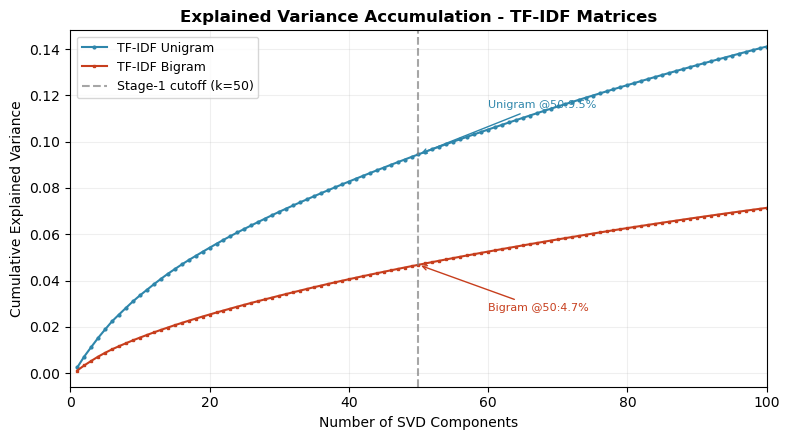


Cumulative variance at 50 components:
 Unigram: 0.0945 (9.5%)
 Bigram:0.0468 (4.7%)


In [6]:
N_SVD_SCAN=min(100,tfidf_uni_matrix.shape[1]-1)

svd_scan_uni=TruncatedSVD(n_components=N_SVD_SCAN, random_state=RANDOM_STATE)
svd_scan_uni.fit(tfidf_uni_matrix)

svd_scan_bi=TruncatedSVD(n_components=N_SVD_SCAN, random_state=RANDOM_STATE)
svd_scan_bi.fit(tfidf_bi_matrix)

cumvar_uni=np.cumsum(svd_scan_uni.explained_variance_ratio_)
cumvar_bi=np.cumsum(svd_scan_bi.explained_variance_ratio_)

fig_elbow, ax_elbow=plt.subplots(figsize=(8,4.5))
ax_elbow.plot(range(1,N_SVD_SCAN+1),cumvar_uni,'o-',markersize=2,label='TF-IDF Unigram',color='#2E86AB')
ax_elbow.plot(range(1,N_SVD_SCAN+1),cumvar_bi,'s-',markersize=2,label='TF-IDF Bigram',color='#C73E1D')

ax_elbow.axvline(x=50,color='gray',linestyle='--',alpha=0.7,label='Stage-1 cutoff (k=50)')
ax_elbow.annotate(f'Unigram @50:{cumvar_uni[49]:.1%}',xy=(50, cumvar_uni[49]),xytext=(60,cumvar_uni[49]+0.02),fontsize=8,arrowprops=dict(arrowstyle='->',color='#2E86AB'),color='#2E86AB')
ax_elbow.annotate(f'Bigram @50:{cumvar_bi[49]:.1%}',xy=(50,cumvar_bi[49]),xytext=(60,cumvar_bi[49]-0.02),fontsize=8,arrowprops=dict(arrowstyle='->',color='#C73E1D'),color='#C73E1D')

ax_elbow.set_xlabel('Number of SVD Components',fontsize=10)
ax_elbow.set_ylabel('Cumulative Explained Variance', fontsize=10)
ax_elbow.set_title('Explained Variance Accumulation - TF-IDF Matrices',fontsize=12, fontweight='bold')
ax_elbow.legend(fontsize=9)
ax_elbow.grid(True,alpha=0.2)
ax_elbow.set_xlim(0,N_SVD_SCAN)

plt.tight_layout()
fig_elbow.savefig(os.path.join(FIGURES_DIR,'explained_variance_elbow.png'),dpi=200,bbox_inches='tight')
plt.show()

print(f"\nCumulative variance at 50 components:")
print(f" Unigram: {cumvar_uni[49]:.4f} ({cumvar_uni[49]:.1%})")
print(f" Bigram:{cumvar_bi[49]:.4f} ({cumvar_bi[49]:.1%})")

## 3 - Dimensionality Reduction

In [9]:
SVD_INTERMEDIATE=50

def reduce_sparse_twostage(matrix,n_svd=SVD_INTERMEDIATE,n_final=2,random_state=RANDOM_STATE):
    """stage 1: TruncatedSVD -> n_svd dimensions
       stage 2:PCA -> n_fianl dimensions (2D)"""
    # stage 1
    svd=TruncatedSVD(n_components=n_svd, random_state=random_state)
    dense_intermediate=svd.fit_transform(matrix)
    evr_stage1_total=svd.explained_variance_ratio_.sum()
    
    #stage 2
    pca=PCA(n_components=n_final,random_state=random_state)
    coords=pca.fit_transform(dense_intermediate)
    evr_stage2=pca.explained_variance_ratio_
    
    evr_effective=evr_stage2*evr_stage1_total
    
    return coords,evr_stage2,evr_effective,evr_stage1_total

def reduce_dense_direct(matrix, n_components=2,random_state=RANDOM_STATE):
    """PCA for dense matrices (SBERT,LDA)"""
    pca=PCA(n_components=n_components,random_state=random_state)
    coords=pca.fit_transform(matrix)
    return coords,pca.explained_Variance_ratio_

coords_uni,evr_s2_uni,evr_eff_uni,evr_s1_uni=reduce_sparse_twostage(tfidf_uni_matrix)
coords_bi,evr_s2_bi,evr_eff_bi,evr_s1_bi=reduce_sparse_twostage(tfidf_bi_matrix)

print("=== Reduction ===")
print(f"\nTF-IDF Unigram:")
print(f" Stage 1 (SVD -> {SVD_INTERMEDIATE}D):captures {evr_s1_uni:.2%} of total variance")
print(f" Stage 2 (PCA -> 2D): PC1={evr_s2_uni[0]:.2%}, PC2={evr_s2_uni[1]:.2%}of the {SVD_INTERMEDIATE}D space")
print(f" Effective (of original):PC1={evr_eff_uni[0]:.2%},PC2={evr_eff_uni[1]:.2%}")
print(f"Effective (of orginal):PC1={evr_eff_bi[0]:.2%}, PC2={evr_eff_bi[1]:.2%}")

#SBERT/LDA
#coords_sbert,evr_sbert=reduce_dense_direct(sbert_matrix)
#coords_lda,evr_lda=reduce_dense_direct(lda_matrix)
#print(f"\nSBERT (direvt PCA):PC1={evr_sbert[0]:.2%},PC2={evr_sbert[1]:.2%},total={evr_sbert,sum():.2%}")
#print(f"LDA (direct PCA):PC1={evr_lda[0]:.2%},PC2={evr_lda[1]:.2%},total={evr_lda.sum():.2%}")


=== Reduction ===

TF-IDF Unigram:
 Stage 1 (SVD -> 50D):captures 9.38% of total variance
 Stage 2 (PCA -> 2D): PC1=5.56%, PC2=4.84%of the 50D space
 Effective (of original):PC1=0.52%,PC2=0.45%
Effective (of orginal):PC1=0.22%, PC2=0.20%


## 4 - Compute Per-Period Centroids

In [11]:
#Sorted period order for trajectory lines
PERIOD_ORDER=sorted(np.unique(period_labels))
print(f"Period order for trajectory:{PERIOD_ORDER}")

def compute_centroids(coords_2d, labels, period_order=PERIOD_ORDER):
    """Compute the mean (centroid) of 2D coordinates for each period.
    Returns dict:{period_label:(cx,cy)} and arrays for plotting."""
    centroids={}
    for p in period_order:
        mask=labels==p
        n=mask.sum()
        if n==0:
            continue
        cx,cy=coords_2d[mask].mean(axis=0)
        centroids[p]=(cx,cy,n)
    return centroids

centroids_uni=compute_centroids(coords_uni,period_labels)
centroids_bi=compute_centroids(coords_bi,period_labels)

#Print centroid summary
print("\nCentroids - TF-IDF Unigram:")
for p, (cx,cy,n) in centroids_uni.items():
    print(f"{p}: ({cx:+.4f},{cy:+.4f}) n={n}")

print("\nCentroids - TF-IDF Bigram:")
for p,(cx,cy,n) in centroids_bi.items():
    print(f"{p}:({cx:+.4f},{cy:+.4f}) n={n}")

Period order for trajectory:['1991-1995', '1996-2000', '2001-2005', '2006-2010', '2011-2015', '2016-2021']

Centroids - TF-IDF Unigram:
1991-1995: (-0.0700,+0.0453) n=448
1996-2000: (-0.0618,+0.0421) n=659
2001-2005: (-0.0617,+0.0380) n=279
2006-2010: (-0.0724,+0.0424) n=364
2011-2015: (-0.0417,+0.0263) n=2066
2016-2021: (+0.0071,-0.0045) n=28405

Centroids - TF-IDF Bigram:
1991-1995:(+0.0052,-0.0067) n=448
1996-2000:(+0.0047,-0.0086) n=659
2001-2005:(+0.0039,-0.0120) n=279
2006-2010:(+0.0038,-0.0113) n=364
2011-2015:(+0.0027,-0.0116) n=2066
2016-2021:(-0.0005,+0.0014) n=28405


## 5 - Trajectory Plot  (PCA/SVD)

In [18]:
#Colour palette: one colour per period, consistent across all subplots
PERIOD_COLOURS={
    '1991-1995':'#2E86AB',
    '1996-2000':'#A23B72',
    '2001-2005':'#F18F01',
    '2006-2010':'#C73E1D',
    '2011-2015':'#3B1F2B',
    '2016-2021':'#44AF69',
}

def smart_offsets(centroids,period_order):
    
    """Compute label offsets that minimise overlap"""
    
    periods=[p for p in period_order if p in centroids]
    coords=np.array([(centroids[p][0],centroids[p][1]) for p in periods])
    offsets={}
    for i, p in enumerate(periods):
        #Alternate above/blow
        y_dir=1 if i % 2 == 0 else -1
        #Base offset
        dx,dy=12,14*y_dir
        #if very close to previous point, push label further out
        if i>0:
            dist=np.linalg.norm(coords[i]-coords[i-1])
            if dist <0.02:
                dx=16
                dy=(18+i*4)*y_dir
        offsets[p]=(dx,dy)
    return offsets

def plot_trajectory(ax,coords_2d,labels,centroids,title,evr_label,show_scatter=True):
    
    periods=[p for p in PERIOD_ORDER if p in centroids]
    offsets=smart_offsets(centroids,PERIOD_ORDER)
    
    #Scatter points
    if show_scatter:
        for p in periods:
            mask=labels==p
            ax.scatter(coords_2d[mask,0],coords_2d[mask,1],c=PERIOD_COLOURS[p],alpha=0.12,s=6,edgecolors='none',rasterized=True)
    
    #Trajectory arrows between consecutive centroids
    for i in range(len(periods)-1):
        x1,y1,_=centroids[periods[i]]
        x2,y2,_=centroids[periods[i+1]]
        ax.annotate('',xy=(x2,y2),xytext=(x1,y1),arrowprops=dict(arrowstyle='->',color='#333333',lw=2.0,connectionstyle='arc3,rad=0.12'))
        
    #Centroid markers
    for p in periods:
        cx,cy,n=centroids[p]
        ax.scatter(cx,cy,c=PERIOD_COLOURS[p],s=140,edgecolors='white',linewidths=2,zorder=5)
        dx,dy=offsets[p]
        #Label with period
        ax.annotate(f'{p}\n(n={n})',(cx,cy),fontsize=6.5,fontweight='bold',textcoords='offset points',xytext=(dx,dy),color=PERIOD_COLOURS[p],path_effects=[pe.withStroke(linewidth=2.5,foreground='white')],
                   arrowprops=dict(arrowstyle='-',color=PERIOD_COLOURS[p],lw=0.8,alpha=0.5))
        
        
    #Axis labels with explained variance
    ax.set_xlabel(evr_label[0],fontsize=9)
    ax.set_ylabel(evr_label[1],fontsize=9)
    ax.set_title(title,fontsize=11,fontweight='bold',pad=10)
    ax.tick_params(labelsize=8)
    ax.grid(True,alpha=0.15)

### Main figure

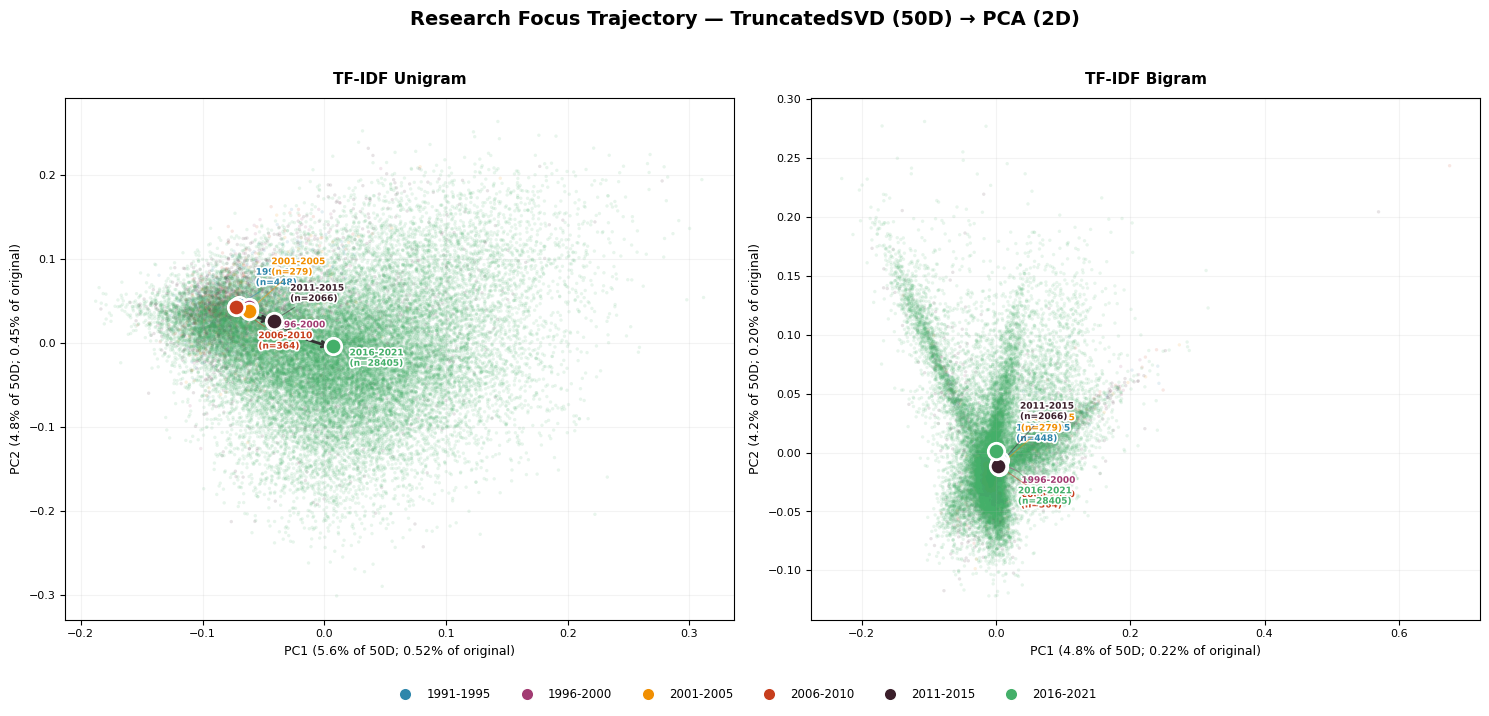

✓ PCA trajectory plots saved.


In [28]:
#Now TF-IDF only
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
fig.suptitle('Research Focus Trajectory — TruncatedSVD (50D) → PCA (2D)',
             fontsize=14, fontweight='bold', y=1.02)

evr_label_uni = [
    f'PC1 ({evr_s2_uni[0]:.1%} of 50D; {evr_eff_uni[0]:.2%} of original)',
    f'PC2 ({evr_s2_uni[1]:.1%} of 50D; {evr_eff_uni[1]:.2%} of original)',
]
evr_label_bi = [
    f'PC1 ({evr_s2_bi[0]:.1%} of 50D; {evr_eff_bi[0]:.2%} of original)',
    f'PC2 ({evr_s2_bi[1]:.1%} of 50D; {evr_eff_bi[1]:.2%} of original)',
]

plot_trajectory(axes[0], coords_uni, period_labels, centroids_uni,
                'TF-IDF Unigram', evr_label_uni)
plot_trajectory(axes[1], coords_bi, period_labels, centroids_bi,
                'TF-IDF Bigram', evr_label_bi)

# Legend
legend_handles = [Line2D([0], [0], marker='o', color='w',
                         markerfacecolor=PERIOD_COLOURS[p], markersize=9, label=p)
                  for p in PERIOD_ORDER]
fig.legend(handles=legend_handles, loc='lower center', ncol=6,
           fontsize=8.5, frameon=False, bbox_to_anchor=(0.5, -0.06))

plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'pca_trajectory_tfidf.png'),
            dpi=200, bbox_inches='tight')

plt.show()
print("✓ PCA trajectory plots saved.")

## 6 - UMAP Comparison

Running Fast UMAP Pipeline on TF-IDF Unigram...

Running Fast UMAP Pipeline on TF-IDF Bigram...


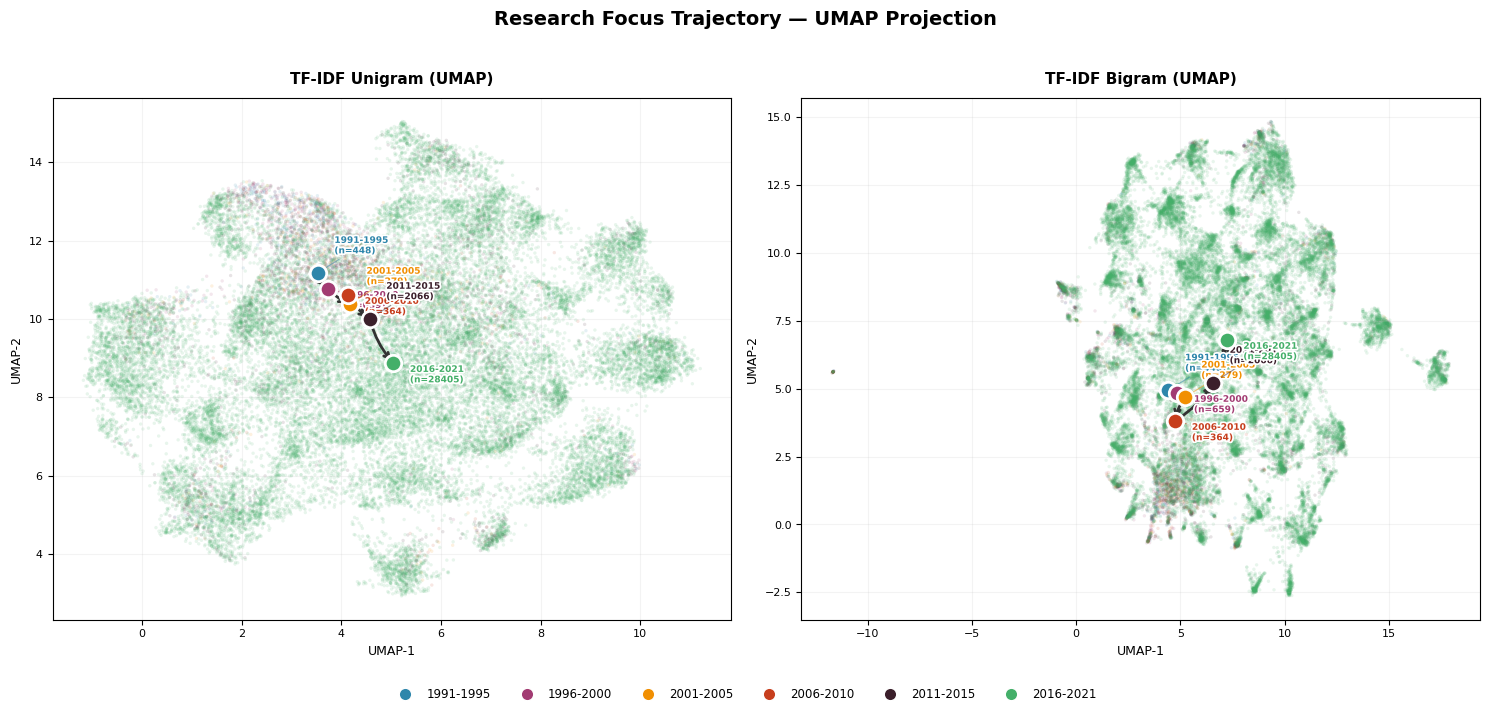

✓ UMAP trajectory plots saved.


In [24]:
if HAS_UMAP:
    def reduce_umap_pipeline(sparse_matrix, n_svd=50, n_neighbors=30, min_dist=0.3, metric='cosine', random_state=RANDOM_STATE):
       
        svd = TruncatedSVD(n_components=n_svd, random_state=random_state)
        dense_50d = svd.fit_transform(sparse_matrix)
        
        dense_50d_norm = normalize(dense_50d, norm='l2')
        
        reducer = umap.UMAP(n_components=2, n_neighbors=n_neighbors, min_dist=min_dist, metric=metric, random_state=random_state)
        coords_2d = reducer.fit_transform(dense_50d_norm)
        
        return coords_2d

    print("Running Fast UMAP Pipeline on TF-IDF Unigram...")
    umap_uni = reduce_umap_pipeline(tfidf_uni_matrix)
    
    print("\nRunning Fast UMAP Pipeline on TF-IDF Bigram...")
    umap_bi  = reduce_umap_pipeline(tfidf_bi_matrix)

    umap_centroids_uni = compute_centroids(umap_uni, period_labels)
    umap_centroids_bi  = compute_centroids(umap_bi,  period_labels)
    # SBERT/LDA ARRIVE
    # print("Running UMAP on SBERT...")
    # umap_sbert = reduce_umap(sbert_matrix)
    # print("Running UMAP on LDA...")
    # umap_lda   = reduce_umap(lda_matrix, metric='hellinger')
    # umap_centroids_sbert = compute_centroids(umap_sbert, period_labels)
    # umap_centroids_lda   = compute_centroids(umap_lda,   period_labels)
    
    fig_u, axes_u = plt.subplots(1, 2, figsize=(15, 6.5))
    fig_u.suptitle('Research Focus Trajectory — UMAP Projection',
                   fontsize=14, fontweight='bold', y=1.02)

    umap_evr_label = ['UMAP-1', 'UMAP-2']

    plot_trajectory(axes_u[0], umap_uni, period_labels, umap_centroids_uni,
                    'TF-IDF Unigram (UMAP)', umap_evr_label)
    plot_trajectory(axes_u[1], umap_bi, period_labels, umap_centroids_bi,
                    'TF-IDF Bigram (UMAP)', umap_evr_label)

    fig_u.legend(handles=legend_handles, loc='lower center', ncol=6,
                 fontsize=8.5, frameon=False, bbox_to_anchor=(0.5, -0.06))

    plt.tight_layout()
    fig_u.savefig(os.path.join(FIGURES_DIR, 'umap_trajectory_comparison.png'),
                  dpi=200, bbox_inches='tight')
    plt.show()
    print("✓ UMAP trajectory plots saved.")
else:
    print("UMAP skipped.")

## 7 - Quantitative Tragectory Analysis

In [25]:
def trajectory_stats(centroids, method_name):
    """Trajectory length, step distances, and largest step"""
    periods = [p for p in PERIOD_ORDER if p in centroids]
    pts = np.array([(centroids[p][0], centroids[p][1]) for p in periods])

    steps = np.diff(pts, axis=0)
    dists = np.linalg.norm(steps, axis=1)
    total = dists.sum()
    imax  = dists.argmax()

    print(f"\n{'─'*50}")
    print(f"  {method_name}")
    print(f"{'─'*50}")
    print(f"  Total trajectory length : {total:.4f}")
    for i, (p1, p2) in enumerate(zip(periods[:-1], periods[1:])):
        marker = " <- MAX" if i == imax else ""
        print(f"    {p1} -> {p2} : {dists[i]:.4f}{marker}")

    return {'method': method_name, 'total': total, 'max_step': dists[imax],
            'max_step_between': f"{periods[imax]} → {periods[imax+1]}",
            'steps': dists}

stats = []
stats.append(trajectory_stats(centroids_uni, "TF-IDF Unigram (SVD -> PCA)"))
stats.append(trajectory_stats(centroids_bi,  "TF-IDF Bigram (SVD -> PCA)"))

if HAS_UMAP:
    stats.append(trajectory_stats(umap_centroids_uni, "TF-IDF Unigram (UMAP)"))
    stats.append(trajectory_stats(umap_centroids_bi,  "TF-IDF Bigram (UMAP)"))

# SBERT/LDA
# stats.append(trajectory_stats(centroids_sbert, "SBERT (PCA)"))
# stats.append(trajectory_stats(centroids_lda,   "LDA (PCA)"))


──────────────────────────────────────────────────
  TF-IDF Unigram (SVD -> PCA)
──────────────────────────────────────────────────
  Total trajectory length : 0.1169
    1991-1995 -> 1996-2000 : 0.0088
    1996-2000 -> 2001-2005 : 0.0041
    2001-2005 -> 2006-2010 : 0.0116
    2006-2010 -> 2011-2015 : 0.0347
    2011-2015 -> 2016-2021 : 0.0577 <- MAX

──────────────────────────────────────────────────
  TF-IDF Bigram (SVD -> PCA)
──────────────────────────────────────────────────
  Total trajectory length : 0.0209
    1991-1995 -> 1996-2000 : 0.0020
    1996-2000 -> 2001-2005 : 0.0035
    2001-2005 -> 2006-2010 : 0.0008
    2006-2010 -> 2011-2015 : 0.0013
    2011-2015 -> 2016-2021 : 0.0134 <- MAX

──────────────────────────────────────────────────
  TF-IDF Unigram (UMAP)
──────────────────────────────────────────────────
  Total trajectory length : 3.2342
    1991-1995 -> 1996-2000 : 0.4531
    1996-2000 -> 2001-2005 : 0.5840
    2001-2005 -> 2006-2010 : 0.2266
    2006-2010 -> 2011

##  8 - Direction Consistency (Axis 1 Comparison)

In [26]:
def overall_direction(centroids):
    """Angle of vector from earliest to latest centroid."""
    periods = [p for p in PERIOD_ORDER if p in centroids]
    first = np.array([centroids[periods[0]][0], centroids[periods[0]][1]])
    last  = np.array([centroids[periods[-1]][0], centroids[periods[-1]][1]])
    delta = last - first
    angle = np.degrees(np.arctan2(delta[1], delta[0]))
    magnitude = np.linalg.norm(delta)
    return angle, magnitude

print("="*50)
print("DIRECTION CONSISTENCY CHECK")
print("="*50)

methods = {
    "TF-IDF Unigram (SVD→PCA)": centroids_uni,
    "TF-IDF Bigram (SVD→PCA)":  centroids_bi,
}

if HAS_UMAP:
    methods["TF-IDF Unigram (UMAP)"] = umap_centroids_uni
    methods["TF-IDF Bigram (UMAP)"]  = umap_centroids_bi

#  SBERT/LDA
# methods["SBERT (PCA)"]  = centroids_sbert
# methods["LDA (PCA)"]    = centroids_lda

angles = {}
for name, c in methods.items():
    angle, mag = overall_direction(c)
    angles[name] = angle
    print(f"  {name:35s}: {angle:+7.1f}°  (magnitude: {mag:.4f})")

# Pairwise angular differences
print(f"\nPairwise angular differences:")
names = list(angles.keys())
for i in range(len(names)):
    for j in range(i + 1, len(names)):
        diff = abs(angles[names[i]] - angles[names[j]])
        if diff > 180:
            diff = 360 - diff
        agreement = "STRONG" if diff < 30 else ("MODERATE" if diff < 60 else "WEAK")
        print(f"  {names[i]:35s} vs {names[j]:35s}: {diff:.1f}° ({agreement})")

DIRECTION CONSISTENCY CHECK
  TF-IDF Unigram (SVD→PCA)           :   -32.9°  (magnitude: 0.0918)
  TF-IDF Bigram (SVD→PCA)            :  +125.2°  (magnitude: 0.0099)
  TF-IDF Unigram (UMAP)              :   -56.6°  (magnitude: 2.7548)
  TF-IDF Bigram (UMAP)               :   +33.6°  (magnitude: 3.3556)

Pairwise angular differences:
  TF-IDF Unigram (SVD→PCA)            vs TF-IDF Bigram (SVD→PCA)            : 158.0° (WEAK)
  TF-IDF Unigram (SVD→PCA)            vs TF-IDF Unigram (UMAP)              : 23.7° (STRONG)
  TF-IDF Unigram (SVD→PCA)            vs TF-IDF Bigram (UMAP)               : 66.5° (WEAK)
  TF-IDF Bigram (SVD→PCA)             vs TF-IDF Unigram (UMAP)              : 178.3° (WEAK)
  TF-IDF Bigram (SVD→PCA)             vs TF-IDF Bigram (UMAP)               : 91.6° (WEAK)
  TF-IDF Unigram (UMAP)               vs TF-IDF Bigram (UMAP)               : 90.2° (WEAK)


## 9 - Era-Based Analysis

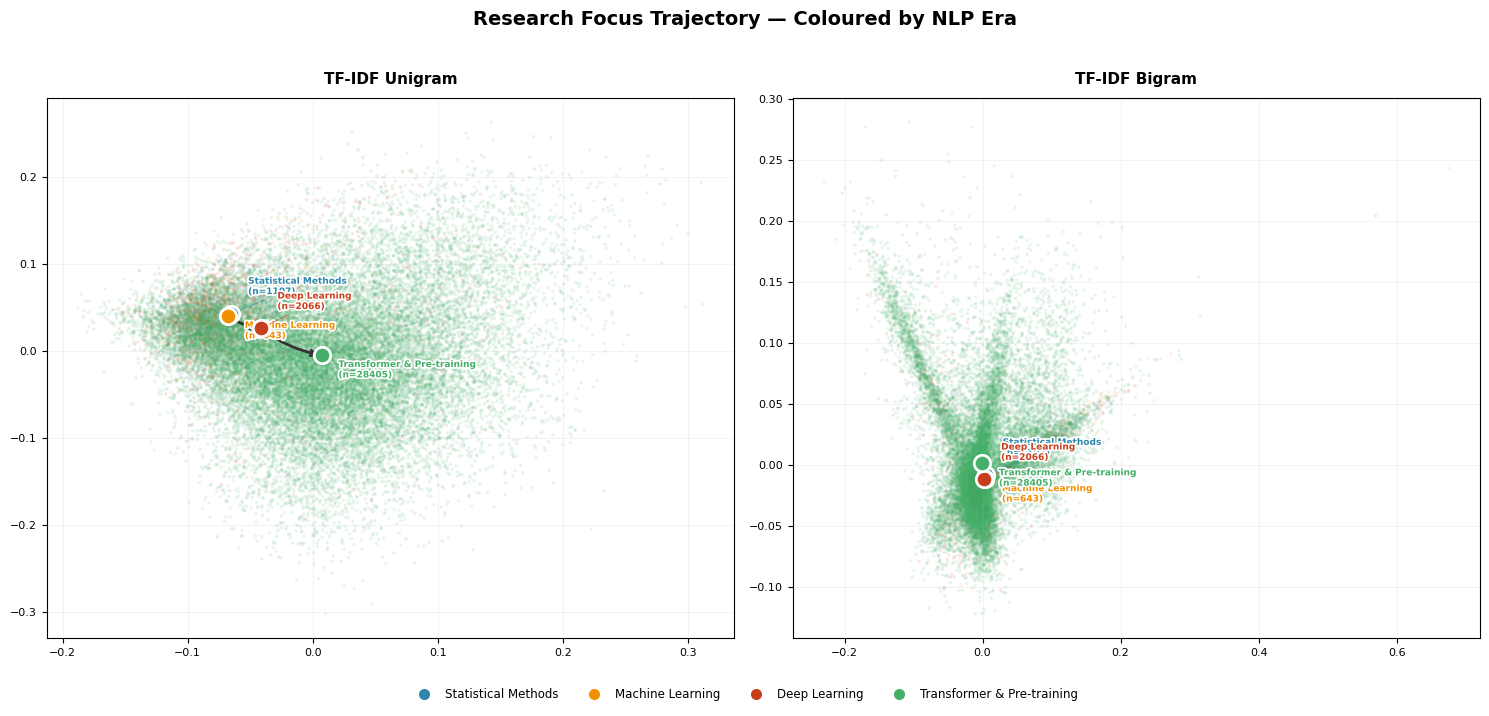

✓ Era trajectory plots saved.


In [27]:
ERA_ORDER = ['Statistical Methods', 'Machine Learning', 'Deep Learning', 'Transformer & Pre-training']
ERA_COLOURS = {
    'Statistical Methods':          '#2E86AB',
    'Machine Learning':             '#F18F01',
    'Deep Learning':                '#C73E1D',
    'Transformer & Pre-training':   '#44AF69',
}

def compute_era_centroids(coords_2d, labels):
    centroids = {}
    for e in ERA_ORDER:
        mask = labels == e
        n = mask.sum()
        if n == 0:
            continue
        cx, cy = coords_2d[mask].mean(axis=0)
        centroids[e] = (cx, cy, n)
    return centroids

era_centroids_uni = compute_era_centroids(coords_uni, era_labels)
era_centroids_bi  = compute_era_centroids(coords_bi,  era_labels)

fig_era, axes_era = plt.subplots(1, 2, figsize=(15, 6.5))
fig_era.suptitle('Research Focus Trajectory — Coloured by NLP Era',
                 fontsize=14, fontweight='bold', y=1.02)

for ax, coords, centroids, title in [
    (axes_era[0], coords_uni, era_centroids_uni, 'TF-IDF Unigram'),
    (axes_era[1], coords_bi,  era_centroids_bi,  'TF-IDF Bigram'),
]:
    eras = [e for e in ERA_ORDER if e in centroids]
    offsets_era = {ERA_ORDER[0]: (12, 14), ERA_ORDER[1]: (12, -16),
                   ERA_ORDER[2]: (12, 14), ERA_ORDER[3]: (12, -16)}

    for e in eras:
        mask = era_labels == e
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   c=ERA_COLOURS[e], alpha=0.12, s=6, edgecolors='none', rasterized=True)

    for i in range(len(eras) - 1):
        x1, y1, _ = centroids[eras[i]]
        x2, y2, _ = centroids[eras[i + 1]]
        ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle='->', color='#333333',
                                    lw=2.0, connectionstyle='arc3,rad=0.12'))

    for e in eras:
        cx, cy, n = centroids[e]
        ax.scatter(cx, cy, c=ERA_COLOURS[e], s=140, edgecolors='white',
                   linewidths=2, zorder=5)
        dx, dy = offsets_era[e]
        ax.annotate(f'{e}\n(n={n})', (cx, cy), fontsize=6.5, fontweight='bold',
                    textcoords='offset points', xytext=(dx, dy),
                    color=ERA_COLOURS[e],
                    path_effects=[pe.withStroke(linewidth=2.5, foreground='white')],
                    arrowprops=dict(arrowstyle='-', color=ERA_COLOURS[e],
                                    lw=0.8, alpha=0.5))

    ax.set_title(title, fontsize=11, fontweight='bold', pad=10)
    ax.tick_params(labelsize=8)
    ax.grid(True, alpha=0.15)

era_handles = [Line2D([0], [0], marker='o', color='w',
                      markerfacecolor=ERA_COLOURS[e], markersize=9, label=e)
               for e in ERA_ORDER]
fig_era.legend(handles=era_handles, loc='lower center', ncol=4,
               fontsize=8.5, frameon=False, bbox_to_anchor=(0.5, -0.06))

plt.tight_layout()
fig_era.savefig(os.path.join(FIGURES_DIR, 'trajectory_by_era.png'),
                dpi=200, bbox_inches='tight')
plt.show()
print("✓ Era trajectory plots saved.")